In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torchvision.models import VGG16_Weights, ResNet18_Weights

from torch.utils.data import DataLoader, Dataset

from pathlib import Path

import pandas as pd

from torchvision.io import read_image

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [32]:
def normalize_bbox(bbox, image_width, image_height):
    x_min, y_min, x_max, y_max = bbox
    x_min = x_min / image_width
    x_max = x_max / image_width
    y_min = y_min / image_height
    y_max = y_max / image_height
    return [x_min, y_min, x_max, y_max]

In [33]:
transform = A.Compose([
    A.Resize(224, 224),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc',label_fields=[]))

In [34]:
#Dataset class
class CustomDataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.annotations = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    #csv文件中，img_name,label,xmin,ymin,xmax,ymax
    def __getitem__(self, idx):
        img_name = self.annotations.iloc[idx, 0]
        img_path = Path(self.root_dir) / img_name
        image = read_image(str(img_path)) / 255.0
        
        bbox = self.annotations.iloc[idx, 2:].values.astype(float)
        bbox = normalize_bbox(bbox, image.shape[2], image.shape[1])
        bboxes = [bbox]

        if self.transform:
            transformed = self.transform(image=image.permute(1, 2, 0).numpy(), bboxes=bboxes)
            image = transformed['image']
            bboxes = transformed['bboxes']

        return image, torch.tensor(bboxes[0], dtype=torch.float32)

In [37]:
# model class
class CustomModel(nn.Module):
    def __init__(self, model_name, num_classes):
        super(CustomModel, self).__init__()

        if model_name == 'vgg16':
            self.model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

            for param in self.model.features.parameters():
                param.requires_grad = False

            with torch.no_grad():
                features = self.model.features(torch.randn(1, 3, 224, 224))
                features_dim = features.view(features.size(0), -1).size(1)
            
            self.model.classifier = nn.Sequential(
                nn.Linear(features_dim, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, num_classes),
                nn.Sigmoid()
            )
        elif model_name == 'resnet18':
            self.model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

            for name, param in self.model.named_parameters():
                if not isinstance(param, nn.Linear):
                    param.requires_grad = False
            
            in_features = self.model.fc.in_features

            self.model.fc = nn.Sequential(
                nn.Linear(in_features, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, num_classes),
                nn.Sigmoid()
            )
        else:
            raise ValueError('Unknown model name: {}'.format(model_name))
        
        print(self.model)

    def forward(self, x):
        return self.model(x)

In [38]:
dataset = CustomDataset(root_dir='./data/banana-detection/bananas_train/images/',
                        csv_file='./data/banana-detection/bananas_train/label.csv',
                        transform=transform)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [42]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

mps


In [43]:
model_name = 'vgg16'
num_classes = 4
model = CustomModel(model_name=model_name, num_classes=num_classes)
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

CustomModel(
  (model): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (1

In [45]:
loss_fd = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 25

for epoch in range(num_epochs):
    for images, bboxes in dataloader:
        images, bboxes = images.to(device), bboxes.to(device)

        outputs = model(images) #预测的bboxes
        loss = loss_fd(outputs, bboxes)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/25], Loss: 0.0075
Epoch [2/25], Loss: 0.0023
Epoch [3/25], Loss: 0.0011
Epoch [4/25], Loss: 0.0004
Epoch [5/25], Loss: 0.0004
Epoch [6/25], Loss: 0.0003
Epoch [7/25], Loss: 0.0003
Epoch [8/25], Loss: 0.0002
Epoch [9/25], Loss: 0.0002
Epoch [10/25], Loss: 0.0002
Epoch [11/25], Loss: 0.0002
Epoch [12/25], Loss: 0.0002
Epoch [13/25], Loss: 0.0002
Epoch [14/25], Loss: 0.0001
Epoch [15/25], Loss: 0.0002
Epoch [16/25], Loss: 0.0001
Epoch [17/25], Loss: 0.0002
Epoch [18/25], Loss: 0.0003
Epoch [19/25], Loss: 0.0001
Epoch [20/25], Loss: 0.0002
Epoch [21/25], Loss: 0.0001
Epoch [22/25], Loss: 0.0003
Epoch [23/25], Loss: 0.0001
Epoch [24/25], Loss: 0.0001
Epoch [25/25], Loss: 0.0002


In [46]:
output_dir=Path('./output')
model_save_path=output_dir/'single_obj_detect.pth'

torch.save(model.state_dict(), model_save_path)

In [48]:
mymodel = CustomModel(model_name='vgg16', num_classes=num_classes).to(device)
mymodel.load_state_dict(torch.load(model_save_path))

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

<All keys matched successfully>

<Figure size 640x480 with 0 Axes>

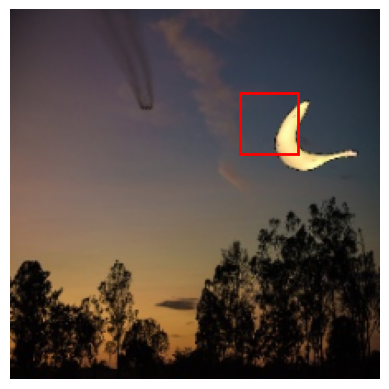

In [56]:
from utils import display_images

model.eval()

test_image_path = './data/banana-detection/bananas_val/images/0.png'
test_image = read_image(test_image_path) / 255.0
test_image = transform(image=test_image.permute(1, 2, 0).numpy())['image']

#display_images(test_image.permute(1, 2, 0))

pre_image = test_image.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(pre_image)
    (startX, startY, endX, endY) = outputs[0].cpu().numpy()

height, width = test_image.shape[1],test_image.shape[2]
startX = int(startX * width)
startY = int(startY * height)
endX = int(endX * width)
endY = int(endY * height)

display_images(test_image.permute(1, 2, 0), bboxes_list=[[(startX, startY, endX, endY)]])
